In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Overlap

In [20]:
df = pd.read_csv("../data/sanitized/upstream_raw.csv")

In [32]:
overlap_df = df.groupby("canonical_smiles").agg({"target_chembl_id": "count"}).sort_values("target_chembl_id", ascending=False)

overlap_df[overlap_df["target_chembl_id"] > 2]

,target_chembl_id
canonical_smiles,
CC/C(=C(\c1ccccc1)c1ccc(OCCN(C)C)cc1)c1ccccc1,10
O=c1c(O)c(-c2ccc(O)c(O)c2)oc2cc(O)cc(O)c12,10
Clc1ccccc1C(c1ccccc1)(c1ccccc1)n1ccnc1,10
OCCN1CCN(CCCN2c3ccccc3Sc3ccc(C(F)(F)F)cc32)CC1,9
CC/C(=C(/CC)c1ccc(O)cc1)c1ccc(O)cc1,9
...,...
CCCn1c(=O)c2nc(-c3cnn(Cc4noc(-c5cccc(OC)c5)n4)c3)[nH]c2n(CCC)c1=O,3
COCc1cccc(CNC(=O)c2cc(-c3ccco3)nc(N)n2)n1,3
OC[C@H]1O[C@@H](n2cnc3c(NCC(c4ccccc4)c4ccccc4)ncnc32)[C@H](O)[C@@H]1O,3


In [33]:
import pandas as pd
import itertools

# usuń duplikaty (ważne!)
df_unique = df[['canonical_smiles', 'target_chembl_id']].drop_duplicates()

# map: target -> set ligandów
target_to_ligands = df_unique.groupby('target_chembl_id')['canonical_smiles'].apply(set).to_dict()

# lista targetów
targets = list(target_to_ligands.keys())

# macierz overlapu
overlap_matrix = pd.DataFrame(0, index=targets, columns=targets, dtype=int)

for t1, t2 in itertools.combinations(targets, 2):
    overlap = len(target_to_ligands[t1] & target_to_ligands[t2])
    overlap_matrix.loc[t1, t2] = overlap
    overlap_matrix.loc[t2, t1] = overlap

# diagonal = liczba ligandów per target
for t in targets:
    overlap_matrix.loc[t, t] = len(target_to_ligands[t])

print(overlap_matrix)

            CHEMBL1865  CHEMBL1941  CHEMBL203  CHEMBL204  CHEMBL205  \
CHEMBL1865        6247           3         35          2          8   
CHEMBL1941           3         315         13          0          3   
CHEMBL203           35          13      10489          1         15   
CHEMBL204            2           0          1       5405          3   
CHEMBL205            8           3         15          3       8473   
CHEMBL206           35           1          7          0          7   
CHEMBL2148          22           0        228          0          1   
CHEMBL217            3          82         15          0          2   
CHEMBL220           17           9         12          2         59   
CHEMBL221            8           2         11          5         16   
CHEMBL224            6          96         17          0          2   
CHEMBL226            3           8          8          2         17   
CHEMBL231            2         176          8          0          1   
CHEMBL

In [34]:
jaccard_matrix = pd.DataFrame(0.0, index=targets, columns=targets)

for t1, t2 in itertools.combinations(targets, 2):
    set1 = target_to_ligands[t1]
    set2 = target_to_ligands[t2]

    inter = len(set1 & set2)
    union = len(set1 | set2)

    score = inter / union if union > 0 else 0.0

    jaccard_matrix.loc[t1, t2] = score
    jaccard_matrix.loc[t2, t1] = score

for t in targets:
    jaccard_matrix.loc[t, t] = 1.0

print(jaccard_matrix)

            CHEMBL1865  CHEMBL1941  CHEMBL203  CHEMBL204  CHEMBL205  \
CHEMBL1865    1.000000    0.000457   0.002096   0.000172   0.000544   
CHEMBL1941    0.000457    1.000000   0.001205   0.000000   0.000341   
CHEMBL203     0.002096    0.001205   1.000000   0.000063   0.000792   
CHEMBL204     0.000172    0.000000   0.000063   1.000000   0.000216   
CHEMBL205     0.000544    0.000341   0.000792   0.000216   1.000000   
CHEMBL206     0.003331    0.000217   0.000474   0.000000   0.000549   
CHEMBL2148    0.001649    0.000000   0.013123   0.000000   0.000064   
CHEMBL217     0.000209    0.009822   0.000807   0.000000   0.000121   
CHEMBL220     0.001441    0.001532   0.000748   0.000182   0.004219   
CHEMBL221     0.001017    0.001029   0.000908   0.000711   0.001586   
CHEMBL224     0.000516    0.017112   0.001072   0.000000   0.000144   
CHEMBL226     0.000273    0.001588   0.000526   0.000197   0.001289   
CHEMBL231     0.000276    0.154522   0.000697   0.000000   0.000106   
CHEMBL

In [35]:
edges = []

for t1, t2 in itertools.combinations(targets, 2):
    overlap = len(target_to_ligands[t1] & target_to_ligands[t2])
    if overlap > 0:
        edges.append((t1, t2, overlap))

edges_df = pd.DataFrame(edges, columns=["target1", "target2", "overlap"])
edges_df = edges_df.sort_values("overlap", ascending=False)

print(edges_df.head(20))

        target1     target2  overlap
282  CHEMBL2835  CHEMBL2971     8378
124  CHEMBL2148  CHEMBL2971     4538
123  CHEMBL2148  CHEMBL2835     4009
24   CHEMBL1865   CHEMBL325     3800
130   CHEMBL217   CHEMBL224     2364
199   CHEMBL226   CHEMBL256     2248
198   CHEMBL226   CHEMBL255     1466
249   CHEMBL255   CHEMBL256     1066
245  CHEMBL2525  CHEMBL2581      521
181   CHEMBL224   CHEMBL240      333
179   CHEMBL224   CHEMBL231      300
212   CHEMBL238   CHEMBL240      298
132   CHEMBL217   CHEMBL231      270
134   CHEMBL217   CHEMBL240      238
49    CHEMBL203  CHEMBL2148      228
111   CHEMBL206   CHEMBL240      186
37   CHEMBL1941   CHEMBL231      176
69    CHEMBL203  CHEMBL3717      165
205   CHEMBL231   CHEMBL240      147
234   CHEMBL240   CHEMBL286      141


In [36]:
target_overlap_score = {}

for t1, t2 in itertools.combinations(targets, 2):
    overlap = len(target_to_ligands[t1] & target_to_ligands[t2])

    target_overlap_score[t1] = target_overlap_score.get(t1, 0) + overlap
    target_overlap_score[t2] = target_overlap_score.get(t2, 0) + overlap

score_df = pd.DataFrame.from_dict(
    target_overlap_score,
    orient='index',
    columns=['total_shared_ligands']
).sort_values('total_shared_ligands', ascending=False)

print(score_df.head(20))


            total_shared_ligands
CHEMBL2971                 13421
CHEMBL2835                 12662
CHEMBL2148                  9045
CHEMBL1865                  4175
CHEMBL325                   4173
CHEMBL226                   3865
CHEMBL256                   3619
CHEMBL224                   3358
CHEMBL217                   3157
CHEMBL255                   2550
CHEMBL240                   2284
CHEMBL231                   1098
CHEMBL203                    969
CHEMBL238                    868
CHEMBL2581                   665
CHEMBL2525                   596
CHEMBL1941                   572
CHEMBL3717                   483
CHEMBL301                    416
CHEMBL260                    327


In [55]:
import pandas as pd
import itertools
import networkx as nx

# usunięcie duplikatów
df_unique = df[['canonical_smiles', 'target_chembl_id']].drop_duplicates()

# target -> set ligandów
target_to_ligands = df_unique.groupby('target_chembl_id')['canonical_smiles'].apply(set).to_dict()

targets = list(target_to_ligands.keys())
MIN_OVERLAP = 100  # zmień np. na 200/500
# graf
G = nx.Graph()

for t in targets:
    G.add_node(t, size=len(target_to_ligands[t]))

for t1, t2 in itertools.combinations(targets, 2):
    overlap = len(target_to_ligands[t1] & target_to_ligands[t2])
    
    if overlap >= MIN_OVERLAP:
        G.add_edge(t1, t2, weight=overlap)

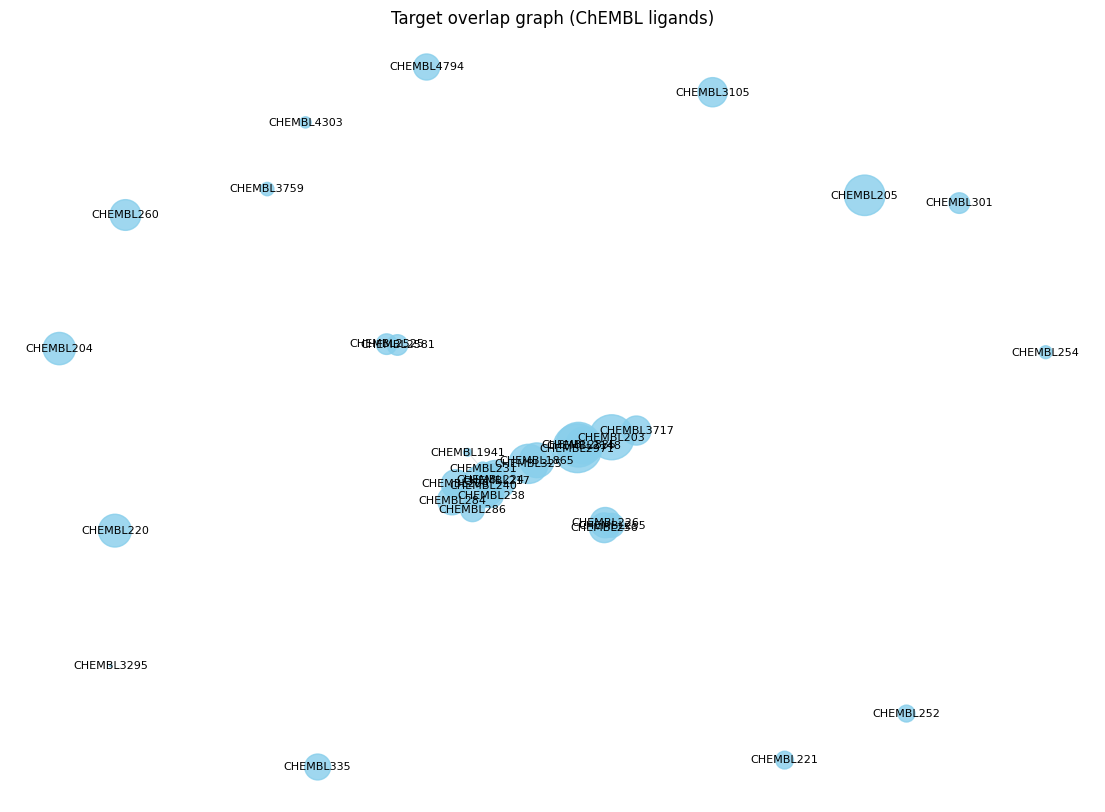

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))

# layout (spring = siłowy)
pos = nx.spring_layout(G, k=0.5, seed=42)

# węzły (rozmiar = liczba ligandów)
node_sizes = [G.nodes[n]['size'] / 10 for n in G.nodes]

# krawędzie (grubość = overlap)
edges = G.edges(data=True)
edge_widths = [d['weight'] / 1000 for (_, _, d) in edges]

nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes,
    node_color='skyblue',
    alpha=0.8
)

nx.draw_networkx_edges(
    G, pos,
    width=edge_widths,
    alpha=0.4
)

nx.draw_networkx_labels(G, pos, font_size=8)

plt.title("Target overlap graph (ChEMBL ligands)")
plt.axis("off")
plt.show()